<a href="https://colab.research.google.com/github/kevinbinu2004-ui/Simulations-Py-/blob/main/Traffic_Signal_Queue_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Traffic Signal Queue Simulation: Updated Algorithm Design (with Dataset Integration)

We will refine our simulation to use the provided `traffic_data_df` for vehicle arrivals, making the traffic patterns more realistic. The core objective remains: simulate a four-way traffic signal and analyze how traffic light timing affects vehicle waiting time, queue length, and road efficiency.

### 1. Simulation Environment
*   **Roads:** Two main roads (North-South and East-West) intersecting at a single point.
*   **Approaches:** Each road has two approaches to the intersection: North, South, East, and West. Each approach is conceptually equipped with its own traffic light, which operates in sync with the main North-South or East-West signal phases.
*   **Traffic Lights:** Two main signal phases operate in an alternating cycle: one for North-South traffic (controlling both North and South approaches) and one for East-West traffic (controlling both East and West approaches).
*   **Vehicles:** Entities that arrive according to the dataset, wait at the red signal, and pass when the signal turns green.

### 2. Key Metrics to Track
*   **Vehicle Waiting Time:** The duration a vehicle spends in a queue from arrival to departure from the intersection.
*   **Queue Length:** The number of vehicles waiting at each approach over time.
*   **Throughput:** The total number of vehicles that successfully pass through the intersection (an indicator of road efficiency).

### 3. Simulation Parameters
We'll define parameters to control the simulation, such as:
*   `simulation_duration`: Now determined by the maximum `time_minute` in the `traffic_data_df`.
*   `green_time_ns`, `yellow_time_ns`: Durations for the North-South green and yellow lights.
*   `green_time_ew`, `yellow_time_ew`: Durations for the East-West green and yellow lights.
*   `max_vehicles_per_step`: The maximum number of vehicles that can clear the intersection from *each* open lane in one time step.
*   `traffic_data_df`: The input DataFrame containing vehicle arrival counts per minute per road.

### 4. Core Logic: The Simulation Loop
The simulation will iterate through discrete time steps, and in each step, the following actions will occur:

#### a. Data-Driven Vehicle Arrivals
*   At each `current_time` (representing `time_minute` from the dataset):
    *   The `vehicle_count` for 'North-South' road is retrieved from `traffic_data_df`.
    *   These vehicles are then distributed evenly (or nearly evenly) between the North and South queues.
    *   Similarly, the `vehicle_count` for 'East-West' road is retrieved.
    *   These vehicles are then distributed evenly between the East and West queues.
*   Each arriving vehicle has its `arrival_time` (current simulation time) recorded and is added to its respective queue.

#### b. Traffic Light State Update
*   The traffic light system cycles through predefined phases: North-South Green -> North-South Yellow -> East-West Green -> East-West Yellow.
*   Each phase has a set duration. When the current phase's time expires, the light transitions to the next phase in the cycle.

#### c. Vehicle Movement (Departure)
*   If a traffic light is green or yellow for a particular direction (e.g., North-South), vehicles in the corresponding queues (North and South) are allowed to pass.
*   Up to `max_vehicles_per_step` vehicles can depart from *each* open lane (e.g., North AND South simultaneously if NS light is green) in a single time step.
*   When a vehicle departs, its `departure_time` is recorded, and its waiting time (`departure_time - arrival_time`) is calculated and stored.

#### d. Data Collection
*   At each time step, the current queue lengths for all approaches are recorded.
*   Information about departed vehicles (arrival time, departure time, waiting time) is stored for post-simulation analysis.

### 5. Post-Simulation Analysis
After the simulation concludes, we will calculate and visualize key metrics:
*   Average and maximum waiting times across all vehicles.
*   Average and maximum queue lengths for each approach.
*   Total throughput of the intersection.
*   Plots of queue lengths over time and waiting time distributions.

This updated approach ensures the simulation is driven by the provided traffic data, offering a more specific analysis of traffic flow under those conditions.

In [6]:
import random
import collections
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Class to represent a single vehicle
class Vehicle:
    def __init__(self, vehicle_id, arrival_time):
        self.vehicle_id = vehicle_id
        self.arrival_time = arrival_time
        self.departure_time = None
        self.waiting_time = None

    def __repr__(self):
        return f"Vehicle(ID={self.vehicle_id}, Arr={self.arrival_time}, Dep={self.departure_time}, Wait={self.waiting_time})"

# Main Traffic Signal Simulation Class
class TrafficSignalSimulation:
    def __init__(self,
                 traffic_data_df: pd.DataFrame,
                 green_time_ns=30,
                 yellow_time_ns=5,
                 green_time_ew=30,
                 yellow_time_ew=5,
                 max_vehicles_per_step=1):

        self.traffic_data_df = traffic_data_df
        self.green_time_ns = green_time_ns
        self.yellow_time_ns = yellow_time_ns
        self.green_time_ew = green_time_ew
        self.yellow_time_ew = yellow_time_ew
        self.max_vehicles_per_step = max_vehicles_per_step

        # Determine simulation duration from data
        self.simulation_duration = self.traffic_data_df['time_minute'].max() + 1

        self.queues = {
            'N': collections.deque(), # North approach
            'S': collections.deque(), # South approach
            'E': collections.deque(), # East approach
            'W': collections.deque()  # West approach
        }

        self.traffic_light_states = {
            'NS_GREEN': green_time_ns,
            'NS_YELLOW': yellow_time_ns,
            'EW_GREEN': green_time_ew,
            'EW_YELLOW': yellow_time_ew
        }

        self.current_state = 'NS_GREEN'
        self.time_in_current_state = 0
        self.current_time = 0
        self.vehicle_id_counter = 0
        self.completed_vehicles = []

        # Data for analysis
        self.queue_lengths_history = {
            'N': [], 'S': [], 'E': [], 'W': [], 'time': []
        }
        self.light_state_history = [] # To record light state at each step

        # Pre-process traffic data for quick lookup
        self.arrival_data_map = self.traffic_data_df.set_index(['time_minute', 'road'])['vehicle_count'].to_dict()

    def _get_next_state(self):
        if self.current_state == 'NS_GREEN':
            return 'NS_YELLOW'
        elif self.current_state == 'NS_YELLOW':
            return 'EW_GREEN'
        elif self.current_state == 'EW_GREEN':
            return 'EW_YELLOW'
        elif self.current_state == 'EW_YELLOW':
            return 'NS_GREEN'

    def _handle_arrivals(self):
        # Get arrival counts from the pre-processed map
        ns_vehicles = self.arrival_data_map.get((self.current_time, 'North-South'), 0)
        ew_vehicles = self.arrival_data_map.get((self.current_time, 'East-West'), 0)

        # Distribute North-South vehicles to N and S queues
        for _ in range(ns_vehicles):
            self.vehicle_id_counter += 1
            new_vehicle = Vehicle(self.vehicle_id_counter, self.current_time)
            if _ % 2 == 0: # Alternate between N and S
                self.queues['N'].append(new_vehicle)
            else:
                self.queues['S'].append(new_vehicle)

        # Distribute East-West vehicles to E and W queues
        for _ in range(ew_vehicles):
            self.vehicle_id_counter += 1
            new_vehicle = Vehicle(self.vehicle_id_counter, self.current_time)
            if _ % 2 == 0: # Alternate between E and W
                self.queues['E'].append(new_vehicle)
            else:
                self.queues['W'].append(new_vehicle)

    def _handle_departures(self):
        passing_queues = []
        if self.current_state in ['NS_GREEN', 'NS_YELLOW']:
            passing_queues.extend([self.queues['N'], self.queues['S']])
        elif self.current_state in ['EW_GREEN', 'EW_YELLOW']:
            passing_queues.extend([self.queues['E'], self.queues['W']])

        for queue in passing_queues:
            for _ in range(self.max_vehicles_per_step):
                if queue:
                    vehicle = queue.popleft()
                    vehicle.departure_time = self.current_time
                    vehicle.waiting_time = vehicle.departure_time - vehicle.arrival_time
                    self.completed_vehicles.append(vehicle)
                else:
                    break # No more vehicles in this queue

    def _record_metrics(self):
        for approach in self.queues.keys():
            self.queue_lengths_history[approach].append(len(self.queues[approach]))
        self.queue_lengths_history['time'].append(self.current_time)
        self.light_state_history.append(self.current_state) # Record light state

    def _get_light_state_at_time(self, t):
        # This method is simplified, assumes light state cycle repeats
        cycle_duration = sum(self.traffic_light_states.values())
        time_in_cycle = t % cycle_duration

        current_cycle_time = 0
        if time_in_cycle < (current_cycle_time + self.traffic_light_states['NS_GREEN']):
            return 'NS_GREEN'
        current_cycle_time += self.traffic_light_states['NS_GREEN']
        if time_in_cycle < (current_cycle_time + self.traffic_light_states['NS_YELLOW']):
            return 'NS_YELLOW'
        current_cycle_time += self.traffic_light_states['NS_YELLOW']
        if time_in_cycle < (current_cycle_time + self.traffic_light_states['EW_GREEN']):
            return 'EW_GREEN'
        current_cycle_time += self.traffic_light_states['EW_GREEN']
        return 'EW_YELLOW'


    def run_simulation(self):
        print(f"Starting simulation for {self.simulation_duration} time steps...")
        for t in range(self.simulation_duration):
            self.current_time = t

            # 1. Handle Vehicle Arrivals (data-driven)
            self._handle_arrivals()

            # 2. Handle Vehicle Departures based on light state
            self._handle_departures()

            # 3. Update Traffic Light State
            self.time_in_current_state += 1
            if self.time_in_current_state >= self.traffic_light_states[self.current_state]:
                self.current_state = self._get_next_state()
                self.time_in_current_state = 0

            # 4. Record Metrics
            self._record_metrics()

        print("Simulation finished.")

    def get_results(self):
        total_waiting_times = [v.waiting_time for v in self.completed_vehicles if v.waiting_time is not None]
        if total_waiting_times:
            avg_waiting_time = np.mean(total_waiting_times)
            max_waiting_time = np.max(total_waiting_times)
        else:
            avg_waiting_time = 0
            max_waiting_time = 0

        avg_queue_lengths = {approach: np.mean(self.queue_lengths_history[approach])
                             for approach in self.queues.keys() if self.queue_lengths_history[approach]}

        total_throughput = len(self.completed_vehicles)

        return {
            'avg_waiting_time': avg_waiting_time,
            'max_waiting_time': max_waiting_time,
            'avg_queue_lengths': avg_queue_lengths,
            'total_throughput': total_throughput,
            'queue_lengths_history': self.queue_lengths_history,
            'completed_vehicles': self.completed_vehicles,
            'light_state_history': self.light_state_history
        }

    def plot_queue_lengths(self):
        plt.figure(figsize=(15, 6))
        for approach in self.queues.keys():
            plt.plot(self.queue_lengths_history['time'], self.queue_lengths_history[approach], label=f'Queue {approach}')
        plt.title('Queue Lengths Over Time')
        plt.xlabel('Time Step')
        plt.ylabel('Number of Vehicles in Queue')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_waiting_time_distribution(self):
        waiting_times = [v.waiting_time for v in self.completed_vehicles if v.waiting_time is not None]
        if not waiting_times:
            print("No completed vehicles to plot waiting time distribution.")
            return

        plt.figure(figsize=(10, 6))
        plt.hist(waiting_times, bins=30, edgecolor='black')
        plt.title('Distribution of Vehicle Waiting Times')
        plt.xlabel('Waiting Time (time steps)')
        plt.ylabel('Number of Vehicles')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_intersection_state(self, time_step):
        if time_step >= len(self.queue_lengths_history['time']) or time_step < 0:
            print(f"Time step {time_step} is out of simulation range (0 to {len(self.queue_lengths_history['time']) - 1}).")
            return

        current_light_state = self.light_state_history[time_step]
        current_queue_lengths = {
            'N': self.queue_lengths_history['N'][time_step],
            'S': self.queue_lengths_history['S'][time_step],
            'E': self.queue_lengths_history['E'][time_step],
            'W': self.queue_lengths_history['W'][time_step]
        }

        # Determine light colors for visualization
        ns_color = 'red'
        ew_color = 'red'
        if 'NS' in current_light_state:
            if 'GREEN' in current_light_state:
                ns_color = 'green'
            elif 'YELLOW' in current_light_state:
                ns_color = 'yellow'
        elif 'EW' in current_light_state:
            if 'GREEN' in current_light_state:
                ew_color = 'green'
            elif 'YELLOW' in current_light_state:
                ew_color = 'yellow'

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.set_aspect('equal', adjustable='box')
        ax.axis('off') # Hide axes

        # Intersection square
        ax.add_patch(plt.Rectangle((-0.5, -0.5), 1, 1, color='gray', alpha=0.5))

        # Roads (simplistic representation)
        ax.plot([-2, 2], [0, 0], color='black', linewidth=8) # East-West
        ax.plot([0, 0], [-2, 2], color='black', linewidth=8) # North-South

        # Queue labels and lights
        # North
        ax.text(0.1, 1.5, f'N: {current_queue_lengths['N']}', ha='center', va='center', fontsize=12)
        ax.scatter(0.3, 0.7, color=ns_color, s=200, edgecolors='black', zorder=5) # NS light indication

        # South
        ax.text(0.1, -1.5, f'S: {current_queue_lengths['S']}', ha='center', va='center', fontsize=12)
        ax.scatter(-0.3, -0.7, color=ns_color, s=200, edgecolors='black', zorder=5) # NS light indication

        # East
        ax.text(1.5, 0.1, f'E: {current_queue_lengths['E']}', ha='center', va='center', fontsize=12)
        ax.scatter(0.7, -0.3, color=ew_color, s=200, edgecolors='black', zorder=5) # EW light indication

        # West
        ax.text(-1.5, 0.1, f'W: {current_queue_lengths['W']}', ha='center', va='center', fontsize=12)
        ax.scatter(-0.7, 0.3, color=ew_color, s=200, edgecolors='black', zorder=5) # EW light indication

        ax.set_title(f'Intersection State at Time Step: {time_step} (Light: {current_light_state})', fontsize=14)
        plt.show()


### Explanation of the Updated Python Code

The `TrafficSignalSimulation` class has been significantly updated to integrate the provided `traffic_data_df`:

1.  **`__init__` (Constructor) Changes:**
    *   Now accepts `traffic_data_df` as a required argument.
    *   `arrival_probability` parameter has been removed as arrivals are no longer random.
    *   `simulation_duration` is dynamically set to `traffic_data_df['time_minute'].max() + 1`, ensuring the simulation runs for the entire duration covered by the dataset.
    *   A new attribute `self.arrival_data_map` is created. This is a dictionary mapping `(time_minute, road_name)` tuples to their corresponding `vehicle_count` for efficient lookup during the simulation.

2.  **`_handle_arrivals()` Changes:**
    *   Instead of using `random.random()`, this method now queries `self.arrival_data_map` for the `vehicle_count` at the `self.current_time` for both 'North-South' and 'East-West' roads.
    *   The total `vehicle_count` for 'North-South' is then distributed into `self.queues['N']` and `self.queues['S']`, alternating vehicles between them to ensure a somewhat even split. (e.g., if 8 vehicles arrive, 4 go to N, 4 to S).
    *   Similarly, 'East-West' vehicles are distributed between `self.queues['E']` and `self.queues['W']`.
    *   Each new vehicle is still assigned a unique `vehicle_id` and its `arrival_time` (the `self.current_time`).

All other methods (`_get_next_state`, `_handle_departures`, `_record_metrics`, `run_simulation`, `get_results`, `plot_queue_lengths`, `plot_waiting_time_distribution`) function as before, but now operate on the traffic patterns defined by your dataset. This makes the simulation's behavior directly reflective of the observed traffic data.

### Running the Data-Driven Simulation and Analyzing Results

Now, let's run the simulation using the provided `traffic_data_df` and our updated `TrafficSignalSimulation` class. We'll use the same green/yellow light timings as before to see how these fixed timings perform under the given traffic load.

Starting simulation for 16 time steps...
Simulation finished.

--- Data-Driven Simulation Results ---
Average Waiting Time: 5.00 time steps
Max Waiting Time: 10.00 time steps
Average Queue Lengths:
  N: 16.00
  S: 14.62
  E: 15.00
  W: 12.50
Total Throughput (Vehicles Passed): 32


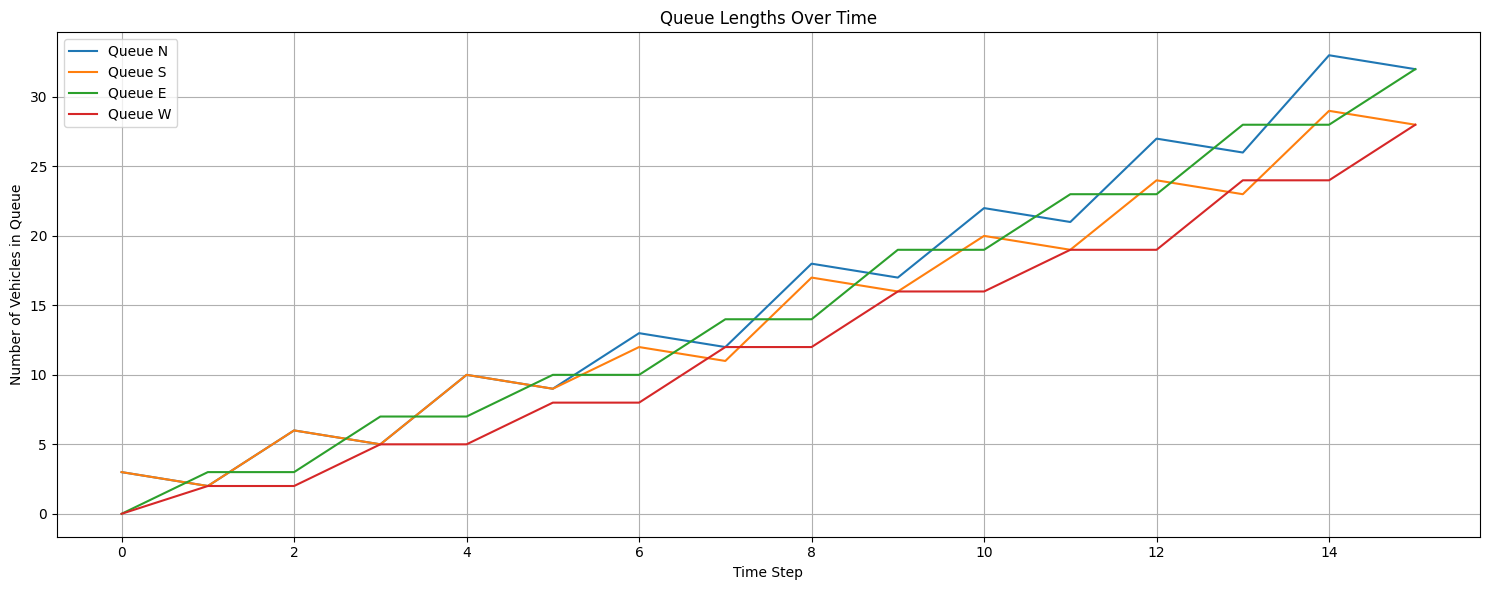

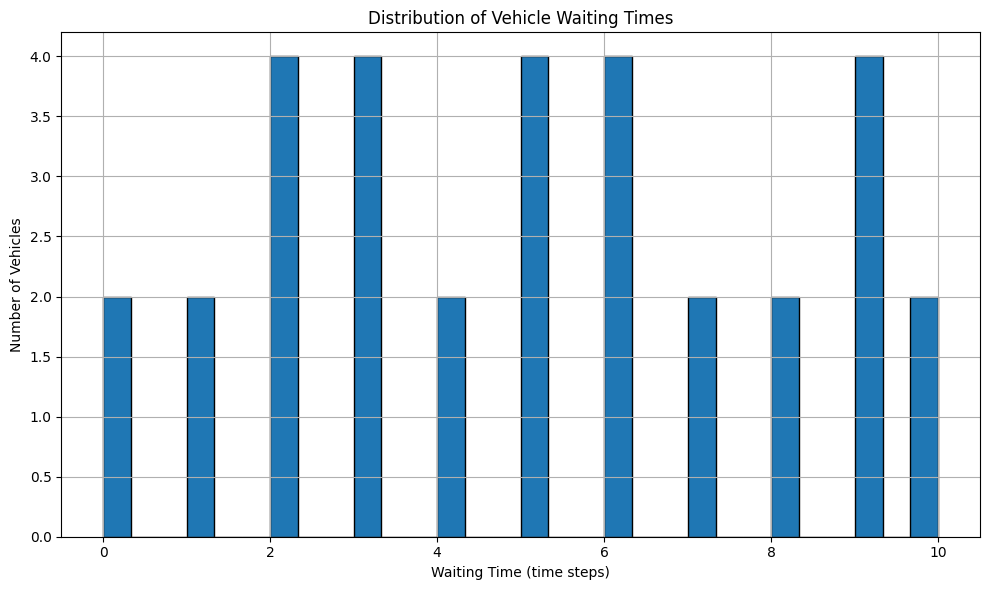

In [5]:
# Ensure traffic_data_df is available (it was loaded in the previous step)
# If you restart the kernel, you might need to re-run the cell that loads zxyyVI.csv

# Initialize and run the simulation with the dataset
sim_data_driven = TrafficSignalSimulation(
    traffic_data_df=traffic_data_df, # Pass the loaded DataFrame
    green_time_ns=30,
    yellow_time_ns=5,
    green_time_ew=30,
    yellow_time_ew=5,
    max_vehicles_per_step=1
)
sim_data_driven.run_simulation()

# Get and display results
results_data_driven = sim_data_driven.get_results()

print("\n--- Data-Driven Simulation Results ---")
print(f"Average Waiting Time: {results_data_driven['avg_waiting_time']:.2f} time steps")
print(f"Max Waiting Time: {results_data_driven['max_waiting_time']:.2f} time steps")
print("Average Queue Lengths:")
for approach, avg_len in results_data_driven['avg_queue_lengths'].items():
    print(f"  {approach}: {avg_len:.2f}")
print(f"Total Throughput (Vehicles Passed): {results_data_driven['total_throughput']}")

# Plotting
sim_data_driven.plot_queue_lengths()
sim_data_driven.plot_waiting_time_distribution()


### Re-running Simulation with Updated Class and Demonstrating Pictorial Simulation

Now that the `TrafficSignalSimulation` class includes the `plot_intersection_state` method and records `light_state_history`, let's re-run the simulation to capture this data and then visualize the intersection at different time steps.

Starting simulation for 16 time steps...
Simulation finished.

--- Re-run Data-Driven Simulation Results (for confirmation) ---
Average Waiting Time: 5.00 time steps
Max Waiting Time: 10.00 time steps
Total Throughput (Vehicles Passed): {results_data_driven['total_throughput']}

--- Pictorial Simulation Snapshots ---


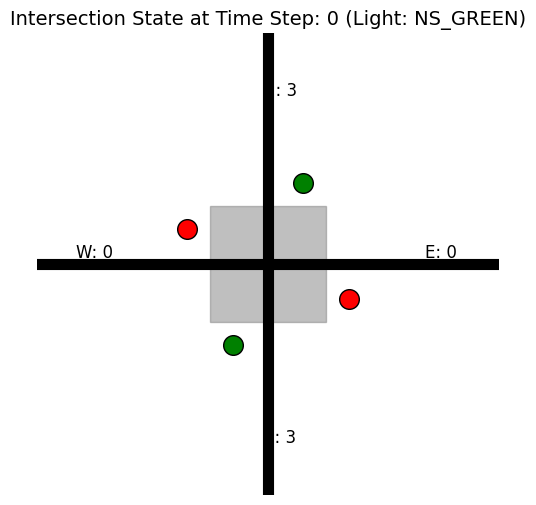

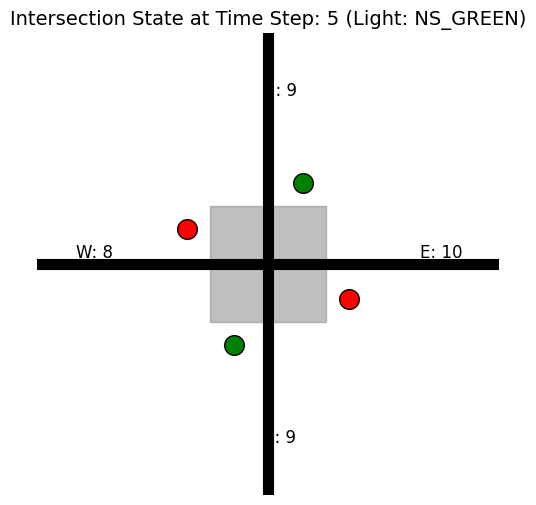

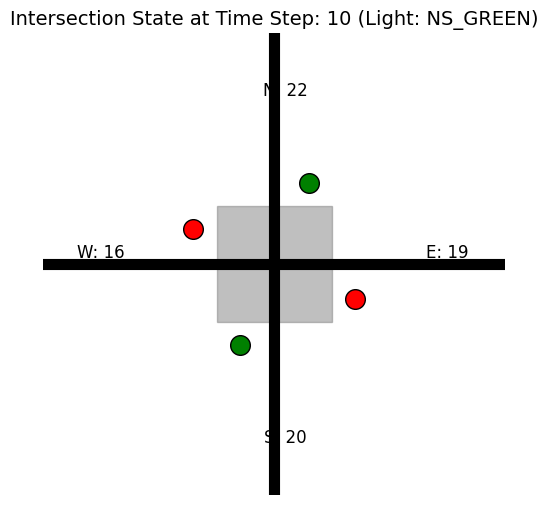

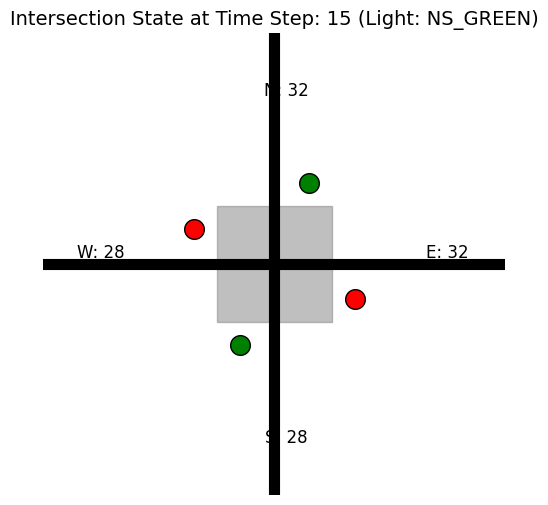

In [7]:
# Re-initialize and re-run the simulation with the dataset to populate light_state_history
sim_data_driven = TrafficSignalSimulation(
    traffic_data_df=traffic_data_df, # Pass the loaded DataFrame
    green_time_ns=30,
    yellow_time_ns=5,
    green_time_ew=30,
    yellow_time_ew=5,
    max_vehicles_per_step=1
)
sim_data_driven.run_simulation()

# Get and display results (optional, already done but good for confirmation)
results_data_driven = sim_data_driven.get_results()

print("\n--- Re-run Data-Driven Simulation Results (for confirmation) ---")
print(f"Average Waiting Time: {results_data_driven['avg_waiting_time']:.2f} time steps")
print(f"Max Waiting Time: {results_data_driven['max_waiting_time']:.2f} time steps")
print("Total Throughput (Vehicles Passed): {results_data_driven['total_throughput']}")

print("\n--- Pictorial Simulation Snapshots ---")
# Visualize intersection at different time steps
# (The simulation duration is 16 time steps, so we pick a few interesting points)

sim_data_driven.plot_intersection_state(0) # Start of simulation
sim_data_driven.plot_intersection_state(5) # Mid-simulation example
sim_data_driven.plot_intersection_state(10) # Another mid-simulation example
sim_data_driven.plot_intersection_state(results_data_driven['queue_lengths_history']['time'][-1]) # End of simulation